# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2  \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2  \\
H_1: p_1 > p_2
$$

ПАРАМЕТРЫ ЗАДАЧИ
p1 = 0.35
p2 = 0.4
α = 0.05 (уровень значимости)
β = 0.2 (мощность теста = 0.8)
δ = 0.050000000000000044 (MDE)

РАСЧЕТ МИНИМАЛЬНОГО РАЗМЕРА ВЫБОРКИ
z_(1-α/2) = 1.9600
z_(1-β) = 0.8416
p̄ = 0.3750
Минимальный размер выборки n = 1471 (на каждую группу)
Общий размер выборки = 2942

ПАРАМЕТРЫ НОРМАЛЬНЫХ РАСПРЕДЕЛЕНИЙ
Первая выборка: N(μ₁=0.3500, σ₁=0.012436)
Вторая выборка: N(μ₂=0.4000, σ₂=0.012773)

95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ
Для p₁: [0.3256, 0.3744]
Для p₂: [0.3750, 0.4250]



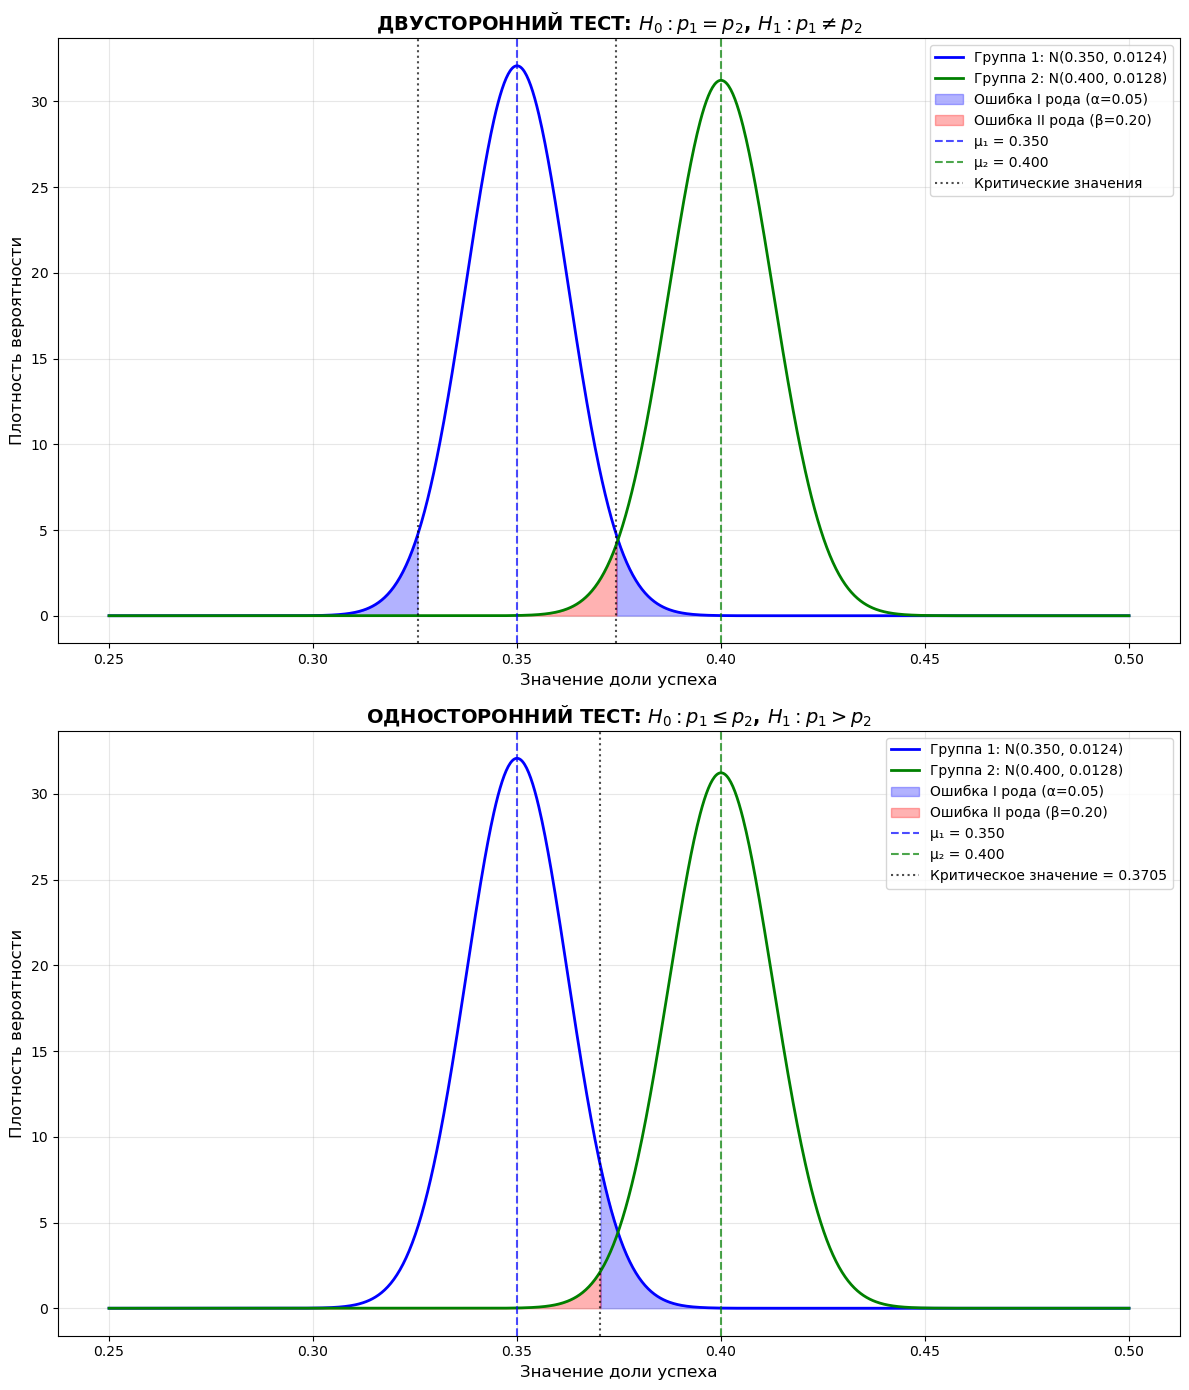

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ
Стандартная ошибка разности: 0.017827
Критическое значение разности: 0.034941
Фактическая мощность теста: 0.8009
Относительный эффект: 14.3%
Доверительные интервалы перекрываются: Нет


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ====================
# 1. ПАРАМЕТРЫ ЗАДАЧИ
# ====================
p1 = 0.35  # вероятность успеха в первой выборке
p2 = 0.40  # вероятность успеха во второй выборке
alpha = 0.05  # уровень значимости
beta = 0.2  # мощность 1 - beta = 0.8
delta = abs(p2 - p1)  # минимальный детектируемый эффект

print("=" * 50)
print("ПАРАМЕТРЫ ЗАДАЧИ")
print("=" * 50)
print(f"p1 = {p1}")
print(f"p2 = {p2}")
print(f"α = {alpha} (уровень значимости)")
print(f"β = {beta} (мощность теста = {1 - beta})")
print(f"δ = {delta} (MDE)")
print()

# ====================================
# 2. РАСЧЕТ МИНИМАЛЬНОГО РАЗМЕРА ВЫБОРКИ
# ====================================
# Квантили нормального распределения
z_alpha_half = stats.norm.ppf(1 - alpha/2)  # z_{1-α/2}
z_beta = stats.norm.ppf(1 - beta)  # z_{1-β}

# Объединенная пропорция
p_bar = (p1 + p2) / 2

# Числитель формулы
numerator = (z_alpha_half * np.sqrt(2 * p_bar * (1 - p_bar)) + 
             z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2

# Знаменатель формулы
denominator = delta**2

# Минимальный размер выборки
n = int(np.ceil(numerator / denominator))

print("=" * 50)
print("РАСЧЕТ МИНИМАЛЬНОГО РАЗМЕРА ВЫБОРКИ")
print("=" * 50)
print(f"z_(1-α/2) = {z_alpha_half:.4f}")
print(f"z_(1-β) = {z_beta:.4f}")
print(f"p̄ = {p_bar:.4f}")
print(f"Минимальный размер выборки n = {n} (на каждую группу)")
print(f"Общий размер выборки = {2 * n}")
print()

# ==========================================
# 3. ПРЕОБРАЗОВАНИЕ К НОРМАЛЬНОМУ РАСПРЕДЕЛЕНИЮ
# ==========================================
# Параметры нормальных распределений через ЦПТ
mu1 = p1
sigma1 = np.sqrt(p1 * (1 - p1) / n)

mu2 = p2
sigma2 = np.sqrt(p2 * (1 - p2) / n)

print("=" * 50)
print("ПАРАМЕТРЫ НОРМАЛЬНЫХ РАСПРЕДЕЛЕНИЙ")
print("=" * 50)
print(f"Первая выборка: N(μ₁={mu1:.4f}, σ₁={sigma1:.6f})")
print(f"Вторая выборка: N(μ₂={mu2:.4f}, σ₂={sigma2:.6f})")
print()

# ==========================================
# 4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ
# ==========================================
# 95% доверительные интервалы
z_conf = stats.norm.ppf(1 - alpha/2)  # z_{0.975}

ci1_lower = p1 - z_conf * np.sqrt(p1 * (1 - p1) / n)
ci1_upper = p1 + z_conf * np.sqrt(p1 * (1 - p1) / n)

ci2_lower = p2 - z_conf * np.sqrt(p2 * (1 - p2) / n)
ci2_upper = p2 + z_conf * np.sqrt(p2 * (1 - p2) / n)

print("=" * 50)
print("95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ")
print("=" * 50)
print(f"Для p₁: [{ci1_lower:.4f}, {ci1_upper:.4f}]")
print(f"Для p₂: [{ci2_lower:.4f}, {ci2_upper:.4f}]")
print()

# ==========================================
# 5. ВИЗУАЛИЗАЦИЯ
# ==========================================
# Создаем сетку значений
x = np.linspace(0.25, 0.50, 1000)

# Плотности распределений
pdf1 = stats.norm.pdf(x, mu1, sigma1)
pdf2 = stats.norm.pdf(x, mu2, sigma2)

# ==========================================
# ГРАФИК 1: ДВУСТОРОННЯЯ АЛЬТЕРНАТИВА
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# График распределений
ax1.plot(x, pdf1, 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f}, {sigma1:.4f})')
ax1.plot(x, pdf2, 'g-', linewidth=2, label=f'Группа 2: N({mu2:.3f}, {sigma2:.4f})')

# Критические значения для двустороннего теста
critical_left = stats.norm.ppf(alpha/2, mu1, sigma1)
critical_right = stats.norm.ppf(1 - alpha/2, mu1, sigma1)

# Область ошибки I рода (α)
x_alpha_left = np.linspace(0.25, critical_left, 100)
x_alpha_right = np.linspace(critical_right, 0.50, 100)

ax1.fill_between(x_alpha_left, stats.norm.pdf(x_alpha_left, mu1, sigma1), 
                  alpha=0.3, color='blue', label=f'Ошибка I рода (α={alpha})')
ax1.fill_between(x_alpha_right, stats.norm.pdf(x_alpha_right, mu1, sigma1), 
                  alpha=0.3, color='blue')

# Область ошибки II рода (β)
# Это область под кривой H1, где мы принимаем H0 (|x| < critical при условии, что верна H1)
x_beta = np.linspace(critical_left, critical_right, 400)
ax1.fill_between(x_beta, stats.norm.pdf(x_beta, mu2, sigma2), 
                  alpha=0.3, color='red', label=f'Ошибка II рода (β={beta:.2f})')

# Вертикальные линии
ax1.axvline(mu1, color='blue', linestyle='--', alpha=0.7, label=f'μ₁ = {mu1:.3f}')
ax1.axvline(mu2, color='green', linestyle='--', alpha=0.7, label=f'μ₂ = {mu2:.3f}')
ax1.axvline(critical_left, color='black', linestyle=':', alpha=0.7, label='Критические значения')
ax1.axvline(critical_right, color='black', linestyle=':', alpha=0.7)

# Настройки графика
ax1.set_title('ДВУСТОРОННИЙ ТЕСТ: $H_0: p_1 = p_2$, $H_1: p_1 \\neq p_2$', fontsize=14, fontweight='bold')
ax1.set_xlabel('Значение доли успеха', fontsize=12)
ax1.set_ylabel('Плотность вероятности', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ==========================================
# ГРАФИК 2: ОДНОСТОРОННЯЯ АЛЬТЕРНАТИВА
# ==========================================
# График распределений
ax2.plot(x, pdf1, 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f}, {sigma1:.4f})')
ax2.plot(x, pdf2, 'g-', linewidth=2, label=f'Группа 2: N({mu2:.3f}, {sigma2:.4f})')

# Критическое значение для одностороннего теста (H1: p1 > p2)
critical_one_sided = stats.norm.ppf(1 - alpha, mu1, sigma1)

# Область ошибки I рода (α) - справа от критического значения
x_alpha_one = np.linspace(critical_one_sided, 0.50, 100)
ax2.fill_between(x_alpha_one, stats.norm.pdf(x_alpha_one, mu1, sigma1), 
                  alpha=0.3, color='blue', label=f'Ошибка I рода (α={alpha})')

# Область ошибки II рода (β) - слева от критического значения при условии H1
x_beta_one = np.linspace(0.25, critical_one_sided, 400)
ax2.fill_between(x_beta_one, stats.norm.pdf(x_beta_one, mu2, sigma2), 
                  alpha=0.3, color='red', label=f'Ошибка II рода (β={beta:.2f})')

# Вертикальные линии
ax2.axvline(mu1, color='blue', linestyle='--', alpha=0.7, label=f'μ₁ = {mu1:.3f}')
ax2.axvline(mu2, color='green', linestyle='--', alpha=0.7, label=f'μ₂ = {mu2:.3f}')
ax2.axvline(critical_one_sided, color='black', linestyle=':', alpha=0.7, 
            label=f'Критическое значение = {critical_one_sided:.4f}')

# Настройки графика
ax2.set_title('ОДНОСТОРОННИЙ ТЕСТ: $H_0: p_1 \\leq p_2$, $H_1: p_1 > p_2$', fontsize=14, fontweight='bold')
ax2.set_xlabel('Значение доли успеха', fontsize=12)
ax2.set_ylabel('Плотность вероятности', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 6. ДОПОЛНИТЕЛЬНЫЕ РАСЧЕТЫ
# ==========================================
print("=" * 50)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ")
print("=" * 50)

# Фактическая мощность теста с найденным n
# Стандартная ошибка разности
se_diff = np.sqrt(p1 * (1 - p1) / n + p2 * (1 - p2) / n)

# Критическое значение в единицах разности
critical_value_diff = z_alpha_half * se_diff

# Мощность теста
z_power = (delta - critical_value_diff) / se_diff
actual_power = stats.norm.cdf(z_power)

print(f"Стандартная ошибка разности: {se_diff:.6f}")
print(f"Критическое значение разности: {critical_value_diff:.6f}")
print(f"Фактическая мощность теста: {actual_power:.4f}")
print(f"Относительный эффект: {(p2 - p1) / p1 * 100:.1f}%")

# Проверка перекрытия доверительных интервалов
overlap = not (ci1_upper < ci2_lower or ci2_upper < ci1_lower)
print(f"Доверительные интервалы перекрываются: {'Да' if overlap else 'Нет'}")